<div style="background-color: #00008B; color: white; text-align: center; padding: 20px; font-size: 2em; font-weight: bold;">
  CAPSTONE PROJECT: EDA.
</div>

In [1]:
from collections import Counter
from datetime import datetime
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.under_sampling import NearMiss
from IPython.display import Image
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from sklearn import svm
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from subprocess import call, check_call
import collections
import gc
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.figure_factory as ff
import plotly.graph_objs as go
import seaborn as sns
#import tensorflow as tf
import time
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('archive.zip')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

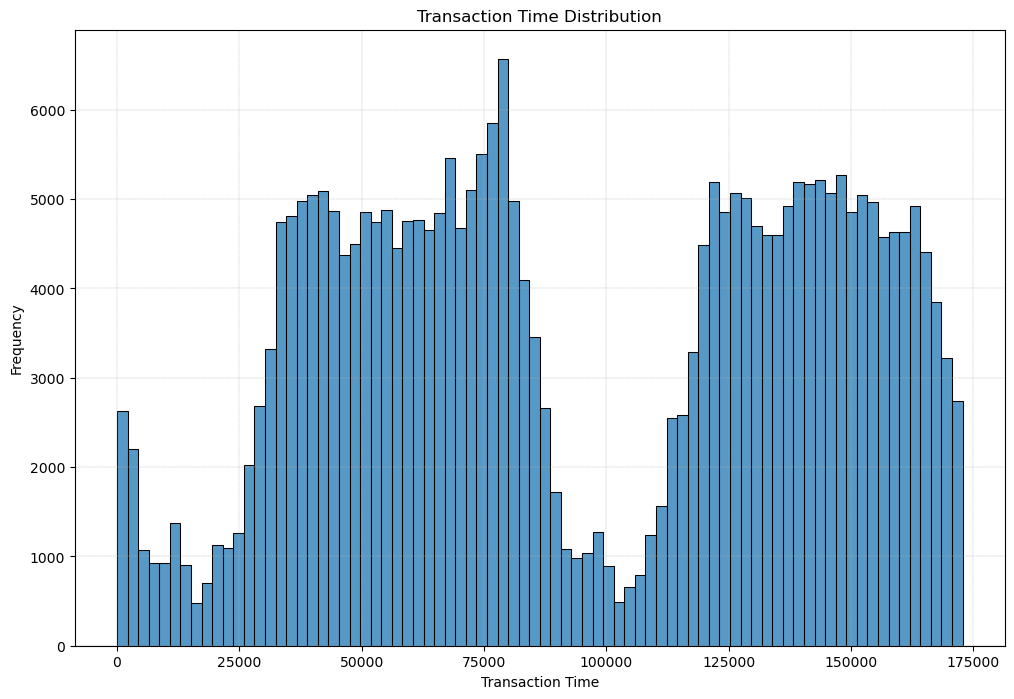

In [8]:
# plot the distribution of transaction time

plt.figure(figsize=(12,8))
ax = sns.histplot(x=df['Time'], bins=80)
plt.title("Transaction Time Distribution")
plt.xlabel("Transaction Time")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--',linewidth=0.3)
plt.savefig('./images/01-time-distribution.png',dpi=300)
plt.show()

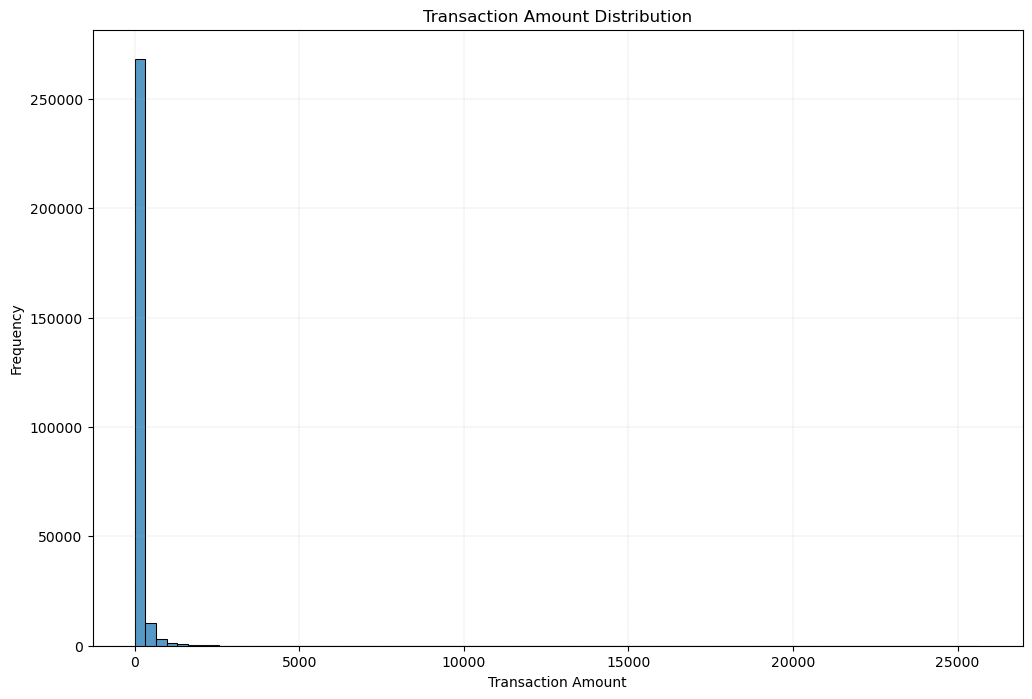

In [9]:
# plot Distribution of Ammount
plt.figure(figsize=(12,8))
ax = sns.histplot(x=df['Amount'], bins=80)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--',linewidth=0.2)
plt.savefig(f'./images/02-amount_distribution.png',dpi=300)
plt.show()

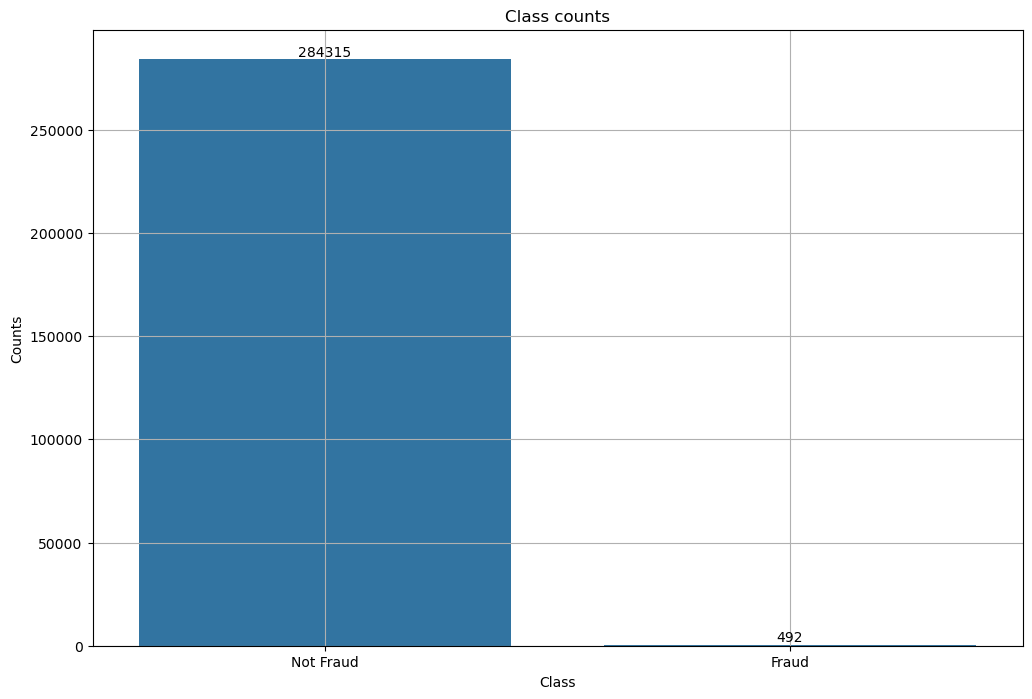

In [10]:
# plot counts of each class
plt.figure(figsize=(12,8))
ax = sns.countplot(x=df['Class'])
plt.title("Class counts")
plt.xlabel("Class")
plt.ylabel("Counts")
plt.xticks([0,1],['Not Fraud', 'Fraud'], rotation=0)
for container in ax.containers:
    ax.bar_label(container)
plt.grid(True)
plt.savefig(f'./images/03-class-counts.png',dpi=300)
plt.show()

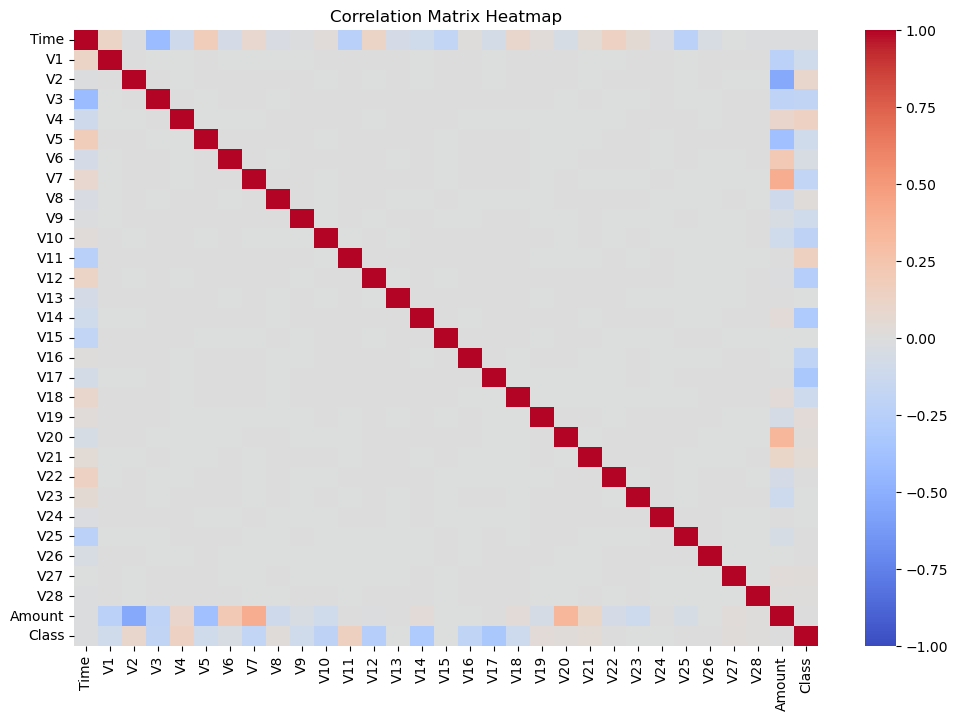

In [11]:
# Calculate and plot the correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
ax = sns.heatmap(corr_matrix, cmap='coolwarm',vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.savefig(f'./images/04-correlation-matrix.png',dpi=300)
plt.show()


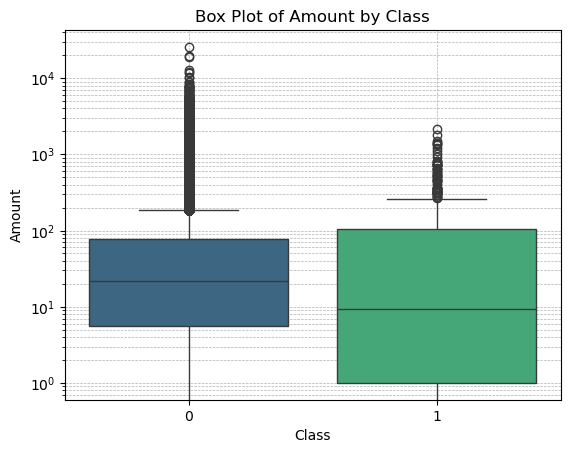

In [12]:
# Box plot of amount by class with outliers

sns.boxplot(x='Class', y='Amount', data=df, palette='viridis')

plt.title('Box Plot of Amount by Class')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f'./images/05-transaction-amount-by-class-with-outliers.png', dpi=300)
plt.show()

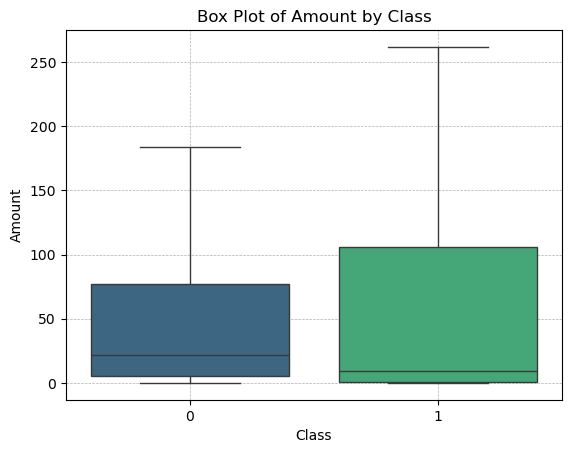

In [13]:
# Box plot of amount by class without outliers

sns.boxplot(x='Class', y='Amount', data=df, palette='viridis', showfliers=False)

plt.title('Box Plot of Amount by Class')
# plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f'./images/06-transaction-amount-by-class-without-outliers.png', dpi=300)
plt.show()

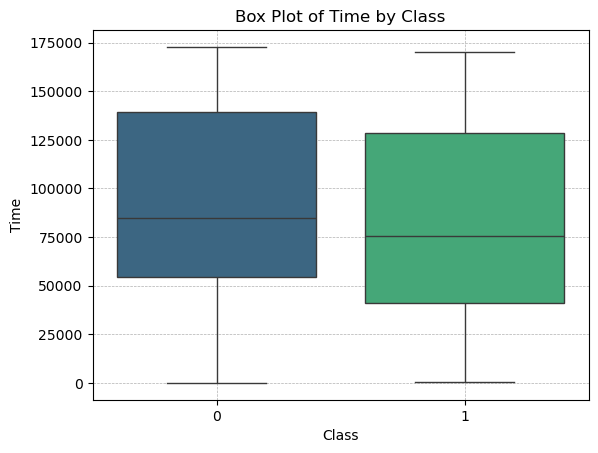

In [14]:
# Box plot of amount by class with outliers

sns.boxplot(x='Class', y='Time', data=df, palette='viridis')

plt.title('Box Plot of Time by Class')
# plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f'./images/07-transaction-time-by-class-with-outliers.png', dpi=300)
plt.show()

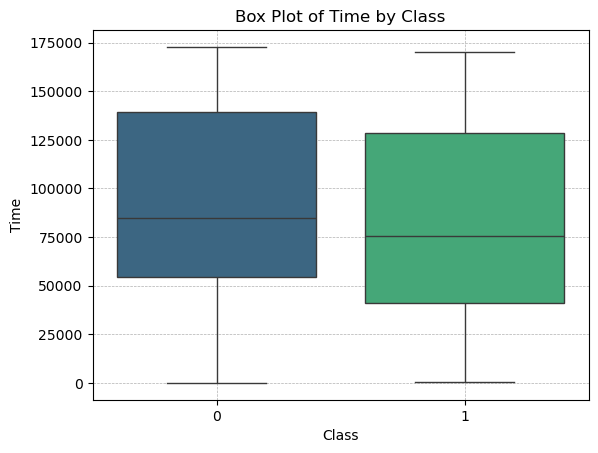

In [15]:
# Box plot of amount by class with outliers

sns.boxplot(x='Class', y='Time', data=df, palette='viridis', showfliers=False)

plt.title('Box Plot of Time by Class')
# plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig(f'./images/08-transaction-time-by-class-without-outliers.png', dpi=300)
plt.show()

In [16]:
# Logistics Regression

factor_cols = df.columns[:-1]
target_col = df.columns[-1]

# 2. Define the ColumnTransformer
# 'passthrough' ensures the target isn't scaled or dropped
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaling', StandardScaler(), factor_cols)
    ],
    remainder='passthrough'
)

# 3. Create the final Pipeline
# This chains the scaling and the classification model
lr_pipeline = Pipeline(steps=[
    ('lr_preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression())
])

# 4. Fit the pipeline
# X contains the first 9 columns, y contains the classification result
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X_train.head()


(227845, 30) (227845,) (56962, 30) (56962,)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
223361,143352.0,1.955041,-0.380783,-0.315013,0.330155,-0.509374,-0.086197,-0.627978,0.035994,1.054560,...,-0.125390,0.238197,0.968305,0.053208,-0.278602,-0.044999,-0.216780,0.045168,-0.047145,9.99
165061,117173.0,-0.400975,-0.626943,1.555339,-2.017772,-0.107769,0.168310,0.017959,-0.401619,0.040378,...,-0.470372,-0.153485,0.421703,0.113442,-1.004095,-1.176695,0.361924,-0.370469,-0.144792,45.90
238186,149565.0,0.072509,0.820566,-0.561351,-0.709897,1.080399,-0.359429,0.787858,0.117276,-0.131275,...,0.012227,-0.314638,-0.872959,0.083391,0.148178,-0.431459,0.119690,0.206395,0.070288,11.99
150562,93670.0,-0.535045,1.014587,1.750679,2.769390,0.500089,1.002270,0.847902,-0.081323,0.371579,...,-0.253757,0.063525,0.443431,-0.072754,0.448192,-0.655203,-0.181038,-0.093013,-0.064931,117.44
138452,82655.0,-4.026938,1.897371,-0.429786,-0.029571,-0.855751,-0.480406,-0.435632,1.313760,0.536044,...,-0.012320,-0.480691,-0.230369,0.250717,0.066399,0.470787,0.245335,0.286904,-0.322672,25.76


In [17]:
# Evaluation the Logistic Regression base model
lr_pipeline.fit(X_train, y_train)

#  Generate default accuracy score
lr_accuracy = lr_pipeline.score(X_test, y_test)
print(f"Test Accuracy of Logistic Regression: {lr_accuracy:.4f}")

# 1. Get the default accuracy score
y_pred = lr_pipeline.predict(X_test)

# Print a comprehensive classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# View the Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy of Logistic Regression: 0.9991

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.92      0.78      0.84     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56854    10]
 [   43    55]]


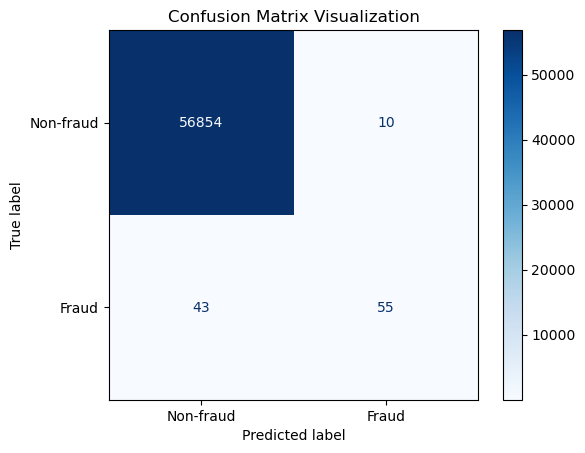

In [18]:
# plot the Confusion Matrix of Logistic Regression base model
cm = np.array([[56854, 10], 
               [43, 55]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-fraud', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix Visualization")
plt.savefig(f'./images/09-Confusion-Matrix-Logistic-Regression.png', dpi=300)
plt.show()

# Summary of Losgistic Regress Base Model

with a total of 56962 test samples, the matrix shows a highly imbalanced dataset with "0 - non-fraud" class predicted with high accuracy 
but the "1 - fraud" class is more difficult for the Logistic Regression model to capture.

True Negative (56,864): the modelcorrectly identified majority of the "0 - non-fraud" class\
True Positive (55): The model correctly identified 55 instances of the target class.\
False Positive (10): the model predicted the target class when it was not there (Type I error).\
False Negative (43): the model missed 43 actual cases of target class(Type II error).

Precision (85%): when the model predicts "positive", it is right for about 85% of times.\
Recall (56%): the model only caught 56% of all actual "Positive" cases.\
F1-score (67%), this is the balance between precision and recall.  A score of 0.67 suggests there is room to improve the model's ability 
to find the minority class without increacing false alarm.